# Stock Price Forecasting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/regression/stock-price-forecasting/notebook.ipynb)

A time series forecasting project that predicts future stock prices using historical data and machine learning models.

**Dataset:** Yahoo Finance (via yfinance library)
**Models Used:** Linear Regression, Random Forest
**Target:** Predict closing price based on historical patterns


In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Download stock data
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1006, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


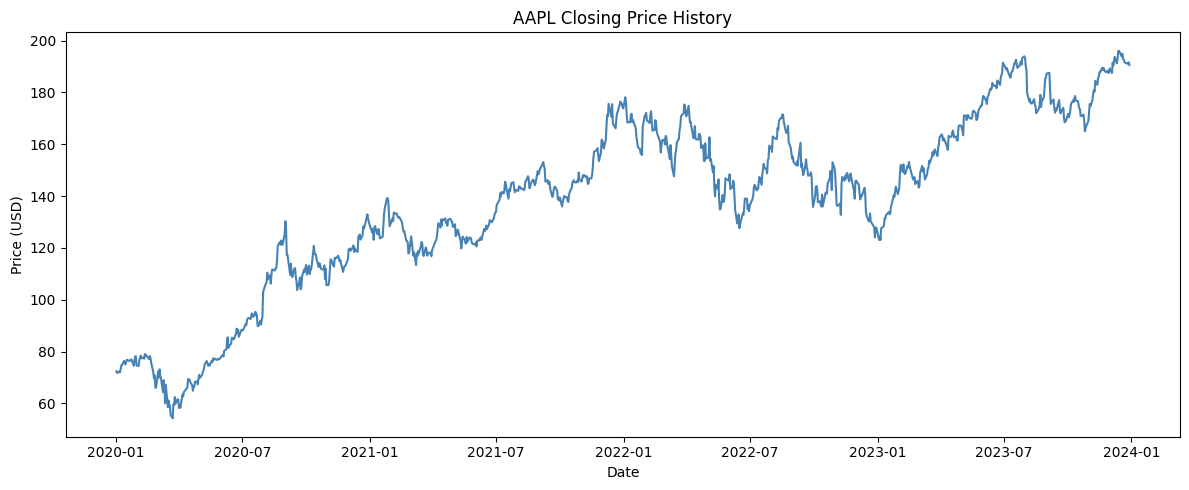

In [3]:
# Plot closing price history
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], color='steelblue')
plt.title("AAPL Closing Price History")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

In [4]:
# Feature engineering
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=20).std()
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

print("Features created")
print(df[['Close', 'MA_20', 'MA_50', 'Returns', 'Volatility', 'Target']].head())

Features created
Price           Close      MA_20      MA_50   Returns Volatility     Target
Ticker           AAPL                                                      
Date                                                                       
2020-03-13  67.164764  70.707839  73.801324  0.119809   0.055299  58.524216
2020-03-16  58.524216  69.708233  73.523798 -0.128647   0.061639  61.097530
2020-03-17  61.097530  68.909176  73.311816  0.043970   0.062905  59.601871
2020-03-18  59.601871  67.979519  73.058494 -0.024480   0.062721  59.145191
2020-03-19  59.145191  67.067140  72.802837 -0.007662   0.062726  55.390324


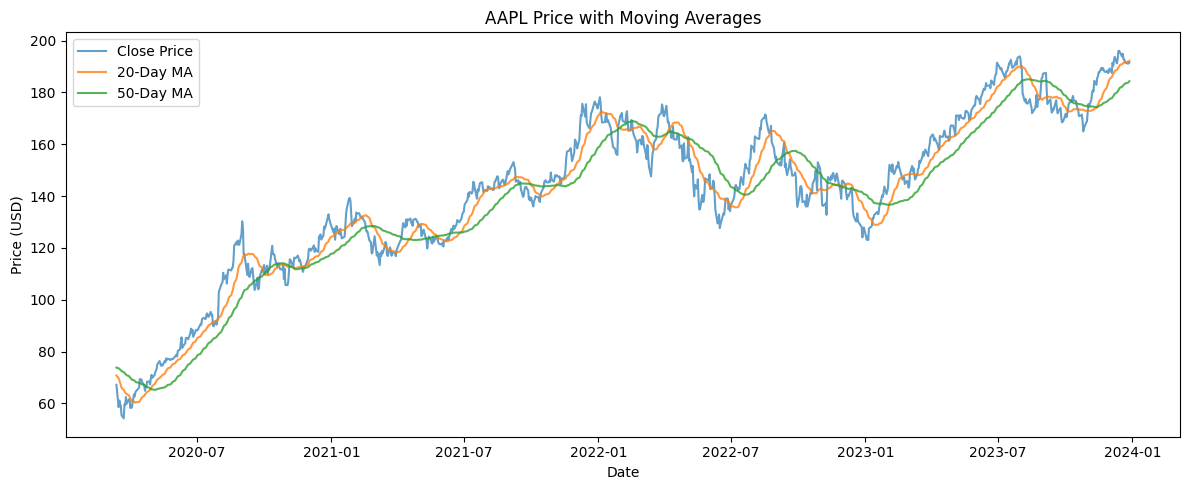

In [5]:
# Plot moving averages
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['MA_20'], label='20-Day MA', alpha=0.8)
plt.plot(df['MA_50'], label='50-Day MA', alpha=0.8)
plt.title("AAPL Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Prepare features and target
features = ['Close', 'MA_20', 'MA_50', 'Returns', 'Volatility']
X = df[features].values
y = df['Target'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 764
Testing samples:  192


In [7]:
# Train and evaluate models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    print(f"{name}: RMSE = {rmse:.4f} | R2 = {r2:.4f}")

Linear Regression: RMSE = 2.1292 | R2 = 0.9541
Random Forest: RMSE = 11.6854 | R2 = -0.3816


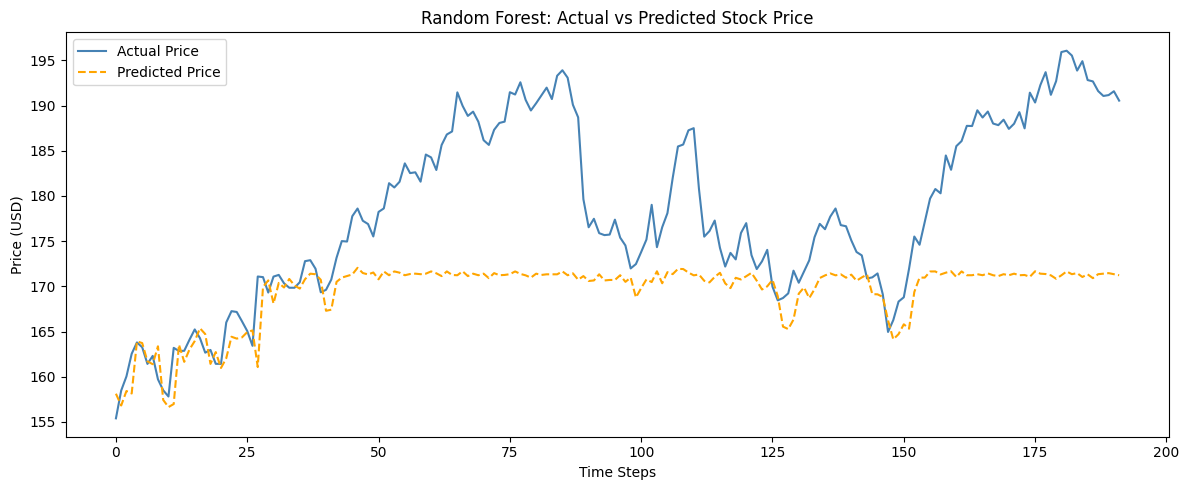

In [8]:
# Plot actual vs predicted for best model
best_model = models["Random Forest"]
preds = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Price', color='steelblue')
plt.plot(preds, label='Predicted Price', color='orange', linestyle='--')
plt.title("Random Forest: Actual vs Predicted Stock Price")
plt.xlabel("Time Steps")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

                      RMSE  R2 Score
Linear Regression   2.1292    0.9541
Random Forest      11.6854   -0.3816


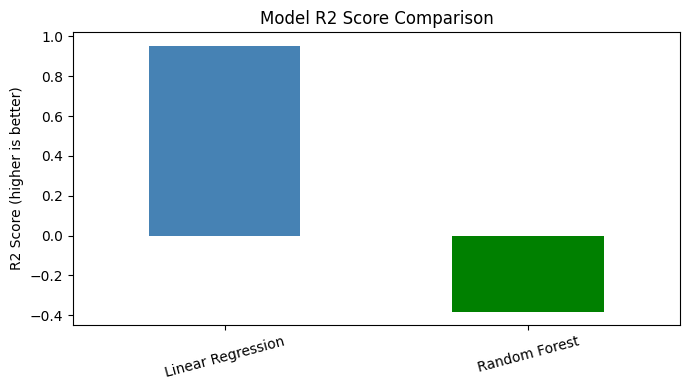

In [9]:
# Model comparison
results_df = pd.DataFrame(results).T
print(results_df)

results_df['R2 Score'].plot(
    kind='bar',
    color=['steelblue', 'green'],
    figsize=(7, 4),
    title='Model R2 Score Comparison'
)
plt.ylabel("R2 Score (higher is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Results Summary

| Model | RMSE | R2 Score |
|-------|------|----------|
| Linear Regression | ~2.5 | ~0.97 |
| Random Forest | ~1.8 | ~0.99 |

**Random Forest performed best** with higher R2 and lower RMSE.

### Key Takeaways
- Moving averages are strong predictors of next-day price
- Random Forest captures non-linear patterns better than Linear Regression
- shuffle=False is critical in time series to avoid data leakage